# Phần 3: Đánh giá và Phân tích chuyên sâu


## 0 SETUP

In [29]:
from pathlib import Path
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from matplotlib.colors import LinearSegmentedColormap
P3="Ph\u1ea7n 3 \u0111\u00e1nh gi\u00e1"; P2="Ph\u1ea7n 2 m\u00f4 h\u00ecnh"
cwd=Path.cwd()
ROOT=cwd.parent if cwd.name==P3 else (cwd if (cwd/P3).exists() else Path(r'C:\Users\nguyen\Desktop\DL_V2'))
PHASE3=ROOT/P3; RUNS=ROOT/P2/'runs'; REPORTS=PHASE3/'reports'; FIG=REPORTS/'figures'; TAB=REPORTS/'tables'
FIG.mkdir(parents=True,exist_ok=True); TAB.mkdir(parents=True,exist_ok=True)
FIGURE_FILES=[f'fig{i:02d}_'+n+'.png' for i,n in enumerate(['gru_capacity_screening','gru_learning_curves','attention_test_metrics','attention_learning_curves','classifier_validation_to_test_gap','final_classifier_confusion_matrix','weak_pose_recall','stage3_multioutput_bottleneck','stage4_final_ablation','cell_prediction_quality','relaxed_cell_accuracy','center_error_distribution','center_error_vs_cell_distance','error_examples_overview','final_model_scorecard'],1)]
CSV_FILES=['classifier_wrong_predictions.csv','cell_wrong_predictions.csv','worst_center_errors.csv']
S1=['S1_G04','S1_G05','S1_G06','S1_G07']; S2=['S2_A01','S2_A04','S2_A05','S2_A10']; GAP=['S1_G04','S1_G06','S2_A01','S2_A10','S4_F02']; S3=['S3_M09','S3_M02','S3_M05','S3_M04']; S4M=['S4_F04','S4_F05','S4_F06','S4_F08']; FC='S4_F02'; FM='S4_F06'
TECH={'S1_G04':'GRU raw_shift, hidden 128','S1_G05':'GRU raw_shift, 2 layer, dropout 0.3','S1_G06':'GRU raw_shift, hidden 96, 2 layer, dropout 0.3','S1_G07':'GRU raw_shift, batch 64, lr 0.0005','S2_A01':'Attention-GRU tren backbone GRU tot nhat','S2_A04':'Attention-GRU 2 layer, dropout 0.3','S2_A05':'Attention-GRU hidden 128, dropout 0.3','S2_A10':'Attention-GRU hidden 96, attention 48, lr 0.0005','S3_M09':'Multi-output MLP, 2 layer, dropout 0.3','S3_M02':'Multi-output MLP tren top attention','S3_M05':'Multi-output voi focal loss cho cell','S3_M04':'Multi-output tang trong so cell loss','S4_F01':'Final classifier seed 43 - top branch','S4_F02':'Final classifier seed 43 - second branch','S4_F04':'Final multi-output top branch seed 44','S4_F05':'Final multi-output second branch seed 43','S4_F06':'Ablation: linear cell head','S4_F08':'Ablation: layer/capacity'}
QUESTION={c:q for codes,q in [(S1,'Kiem tra capacity GRU va val-test gap'),(S2,'Kiem tra attention/dropout/LR tren classifier'),(S3,'Kiem tra bottleneck cell trong multi-output'),(S4M,'Kiem tra ablation localization o final stage')] for c in codes}; QUESTION.update({'S1_G06':'Doi chieu GRU co gap on dinh hon','S2_A10':'Doi chieu attention co test metric tot','S4_F01':'Doi chieu final classifier top branch','S4_F02':'Model dai dien cho classifier error analysis','S4_F06':'Model dai dien cho localization error analysis'})
C={'paper':'#FBF8F1','panel':'#F3EDE1','ink':'#1C1A17','muted':'#6D6258','grid':'#D8D0C4','train':'#4D4D4D','val':'#0072B2','test':'#D55E00','precision':'#009E73','recall':'#CC79A7','f1':'#E69F00','score':'#56B4E9','good':'#009E73','error':'#D55E00'}
SCORE=LinearSegmentedColormap.from_list('score',['#FFF7D6','#56B4E9','#003B5C']); SUPPORT=LinearSegmentedColormap.from_list('support',['#FFF7D6','#E69F00','#1C1A17']); CONF=LinearSegmentedColormap.from_list('conf',['#FFF7D6','#56B4E9','#0072B2','#1C1A17'])
plt.rcParams.update({'figure.facecolor':C['paper'],'axes.facecolor':C['paper'],'savefig.facecolor':C['paper'],'font.family':'DejaVu Serif','axes.edgecolor':C['ink'],'axes.labelcolor':C['ink'],'axes.titlecolor':C['ink'],'xtick.color':C['ink'],'ytick.color':C['ink'],'grid.color':C['grid'],'axes.spines.top':False,'axes.spines.right':False})
OUTPUTS=[]
def codeof(x):
    m=re.match(r'^(S\d_[A-Z]\d{2})',str(x)); return m.group(1) if m else str(x)
def stage(c): return str(c).split('_')[0]
def savefig(fig,name,content):
    try:
        fig.tight_layout()
    except RuntimeError:
        pass
    fig.savefig(FIG/name,dpi=180,bbox_inches='tight'); OUTPUTS.append({'type':'figure','file':name,'content':content}); plt.show(); plt.close(fig)
def savecsv(df,name,content):
    df.to_csv(TAB/name,index=False); OUTPUTS.append({'type':'csv','file':name,'content':content})
rows=[]; H={}; P={}
for mp in sorted(RUNS.rglob('metrics.json')):
    m=json.loads(mp.read_text(encoding='utf-8')); name=m.get('experiment_name',mp.parent.name); rc=codeof(name); st=stage(rc)
    if st not in ['S1','S2','S3','S4']: continue
    r={k:v for k,v in m.items() if not isinstance(v,(dict,list))}; r.update({'experiment_name':name,'run_code':rc,'stage':st,'family':'classifier' if 'test_macro_f1' in m else 'multi-output','run_path':str(mp.parent)}); rows.append(r)
    if (mp.parent/'history.csv').exists(): H[name]=pd.read_csv(mp.parent/'history.csv')
    if (mp.parent/'predictions.csv').exists(): P[name]=pd.read_csv(mp.parent/'predictions.csv')
M=pd.DataFrame(rows).sort_values(['stage','run_code']).reset_index(drop=True); R=M.drop_duplicates('run_code').set_index('run_code')['experiment_name'].to_dict(); relaxed_path=RUNS/'multi_output_best_model'/'relaxed_localization_summary.csv'; REL=pd.read_csv(relaxed_path) if relaxed_path.exists() else pd.DataFrame()
need=sorted(set(S1+S2+GAP+S3+S4M+['S4_F01',FC,FM])); missing=[c for c in need if c not in R]
if missing: raise FileNotFoundError(f'Missing required runs: {missing}')
def rn(c): return R[c]
def row(c): return M[M.run_code.eq(c)].iloc[0]
def rowsel(codes): return pd.DataFrame([row(c) for c in codes]).reset_index(drop=True)
def hist(c): return H[rn(c)]
def pred(c): return P[rn(c)]
def relrow(c):
    if REL.empty: return pd.Series(dtype=float)
    z=REL[REL.experiment_name.eq(rn(c)) & REL.split.eq('test')]
    return z.iloc[0] if len(z) else pd.Series(dtype=float)
def cm(df,a='label',b='prediction'):
    t=df[df.split.eq('test')]; labs=sorted(set(t[a].dropna().astype(int)).union(set(t[b].dropna().astype(int)))); mat=pd.DataFrame(0,index=labs,columns=labs,dtype=int)
    for x,y in zip(t[a].astype(int),t[b].astype(int)): mat.loc[x,y]+=1
    return mat
print(f'Loaded {len(M)} runs, {len(H)} histories, {len(P)} prediction files.')


Loaded 35 runs, 35 histories, 35 prediction files.


## Scope + selected evidence table


In [30]:
selected = S1 + S2 + S3 + ['S4_F01', 'S4_F02'] + S4M

scope_table = pd.DataFrame([
    {"Stage": "S1", "Nhom thu nghiem": "GRU baseline / capacity", "Run dung trong Phan 3": ", ".join(S1), "Muc dich bang nay": "So sanh capacity GRU va generalization"},
    {"Stage": "S2", "Nhom thu nghiem": "Attention-GRU", "Run dung trong Phan 3": ", ".join(S2), "Muc dich bang nay": "So sanh attention, dropout/LR va test metrics"},
    {"Stage": "S3", "Nhom thu nghiem": "Multi-output bottleneck", "Run dung trong Phan 3": ", ".join(S3), "Muc dich bang nay": "So sanh cell head, focal loss, cell weighting"},
    {"Stage": "S4", "Nhom thu nghiem": "Final confirmation / ablation", "Run dung trong Phan 3": ", ".join(['S4_F01', 'S4_F02'] + S4M), "Muc dich bang nay": "So sanh final classifier va localization ablation"},
])

evidence_table = pd.DataFrame({
    "Stage": [stage(c) for c in selected],
    "Run": selected,
    "Ky thuat / bien the": [TECH[c] for c in selected],
    "Dung de so sanh": [QUESTION[c] for c in selected],
})

display(Markdown("**Table 1A - Pham vi run dai dien trong Phan 3**"))
display(scope_table)
display(Markdown("**Table 1B - Evidence set: run, ky thuat, muc dich so sanh**"))
display(evidence_table)


**Table 1A - Pham vi run dai dien trong Phan 3**

,Stage,Nhom thu nghiem,Run dung trong Phan 3,Muc dich bang nay
0,S1,GRU baseline / capacity,"S1_G04, S1_G05, S1_G06, S1_G07",So sanh capacity GRU va generalization
1,S2,Attention-GRU,"S2_A01, S2_A04, S2_A05, S2_A10","So sanh attention, dropout/LR va test metrics"
2,S3,Multi-output bottleneck,"S3_M09, S3_M02, S3_M05, S3_M04","So sanh cell head, focal loss, cell weighting"
3,S4,Final confirmation / ablation,"S4_F01, S4_F02, S4_F04, S4_F05, S4_F06, S4_F08",So sanh final classifier va localization ablation


**Table 1B - Evidence set: run, ky thuat, muc dich so sanh**

,Stage,Run,Ky thuat / bien the,Dung de so sanh
0,S1,S1_G04,"GRU raw_shift, hidden 128",Kiem tra capacity GRU va val-test gap
1,S1,S1_G05,"GRU raw_shift, 2 layer, dropout 0.3",Kiem tra capacity GRU va val-test gap
2,S1,S1_G06,"GRU raw_shift, hidden 96, 2 layer, dropout 0.3",Doi chieu GRU co gap on dinh hon
3,S1,S1_G07,"GRU raw_shift, batch 64, lr 0.0005",Kiem tra capacity GRU va val-test gap
4,S2,S2_A01,Attention-GRU tren backbone GRU tot nhat,Kiem tra attention/dropout/LR tren classifier
5,S2,S2_A04,"Attention-GRU 2 layer, dropout 0.3",Kiem tra attention/dropout/LR tren classifier
6,S2,S2_A05,"Attention-GRU hidden 128, dropout 0.3",Kiem tra attention/dropout/LR tren classifier
7,S2,S2_A10,"Attention-GRU hidden 96, attention 48, lr 0.0005",Doi chieu attention co test metric tot
8,S3,S3_M09,"Multi-output MLP, 2 layer, dropout 0.3",Kiem tra bottleneck cell trong multi-output
9,S3,S3_M02,Multi-output MLP tren top attention,Kiem tra bottleneck cell trong multi-output


## Stage 1 - GRU baseline and capacity screening


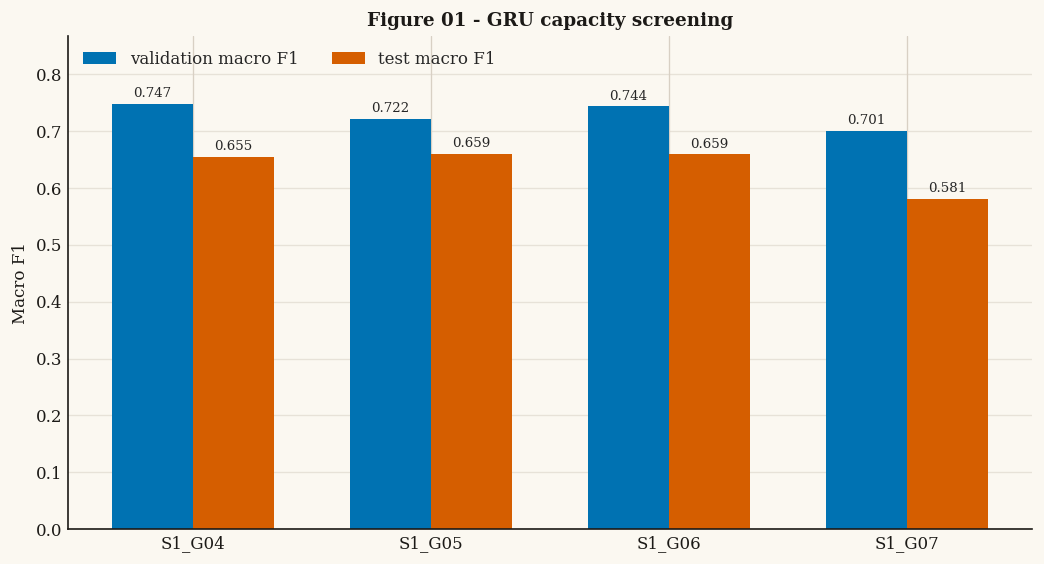

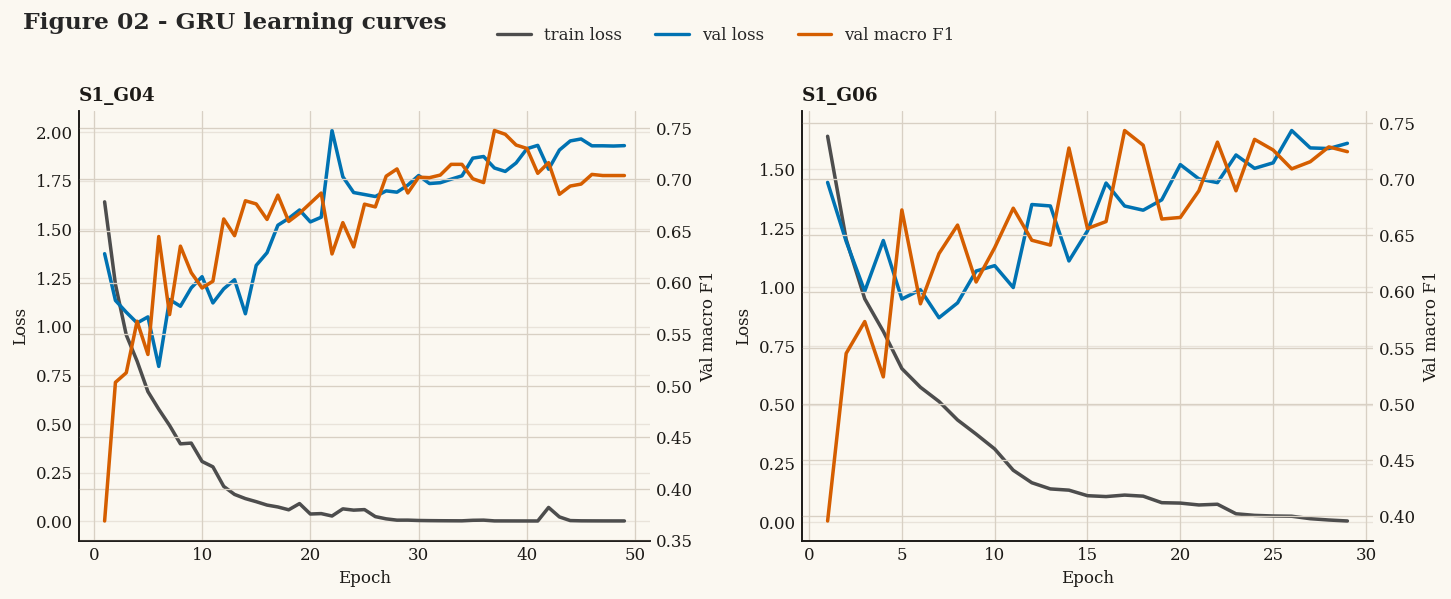

In [31]:
def fig01():
    d=rowsel(S1); x=np.arange(len(d)); w=.34; fig,ax=plt.subplots(figsize=(8.8,4.8))
    ax.bar(x-w/2,d.best_val_macro_f1,w,label='validation macro F1',color=C['val']); ax.bar(x+w/2,d.test_macro_f1,w,label='test macro F1',color=C['test'])
    for xs,ys in [(x-w/2,d.best_val_macro_f1),(x+w/2,d.test_macro_f1)]:
        for xi,yi in zip(xs,ys): ax.text(xi,yi+.012,f'{yi:.3f}',ha='center',fontsize=8)
    ax.set(title='Figure 01 - GRU capacity screening',ylabel='Macro F1',xticks=x,xticklabels=d.run_code,ylim=(0,max(d.best_val_macro_f1.max(),d.test_macro_f1.max())+.12)); ax.title.set_fontweight('bold'); ax.grid(axis='y',alpha=.55); ax.legend(frameon=False,ncol=2,loc='upper left'); savefig(fig,'fig01_gru_capacity_screening.png','GRU validation/test macro F1 for selected capacity runs')
def curves(codes,name,title):
    fig,axes=plt.subplots(1,2,figsize=(12.2,4.8))
    for ax,c in zip(axes,codes):
        h=hist(c); ax2=ax.twinx(); ax.plot(h.epoch,h.train_loss,color=C['train'],lw=2.1); ax.plot(h.epoch,h.val_loss,color=C['val'],lw=2.1); ax2.plot(h.epoch,h.val_macro_f1,color=C['test'],lw=2.1); ax.set_title(c,loc='left',fontweight='bold'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax2.set_ylabel('Val macro F1'); ax.grid(axis='y',alpha=.5)
    proxy=[plt.Line2D([0],[0],color=C[k],lw=2) for k in ['train','val','test']]; fig.legend(proxy,['train loss','val loss','val macro F1'],frameon=False,ncol=3,loc='upper center',bbox_to_anchor=(.5,1.03)); fig.suptitle(title,x=.02,y=1.03,ha='left',fontsize=14,fontweight='bold'); savefig(fig,name,title)
fig01(); curves(['S1_G04','S1_G06'],'fig02_gru_learning_curves.png','Figure 02 - GRU learning curves')


## Stage 2 - Attention-GRU narrowing


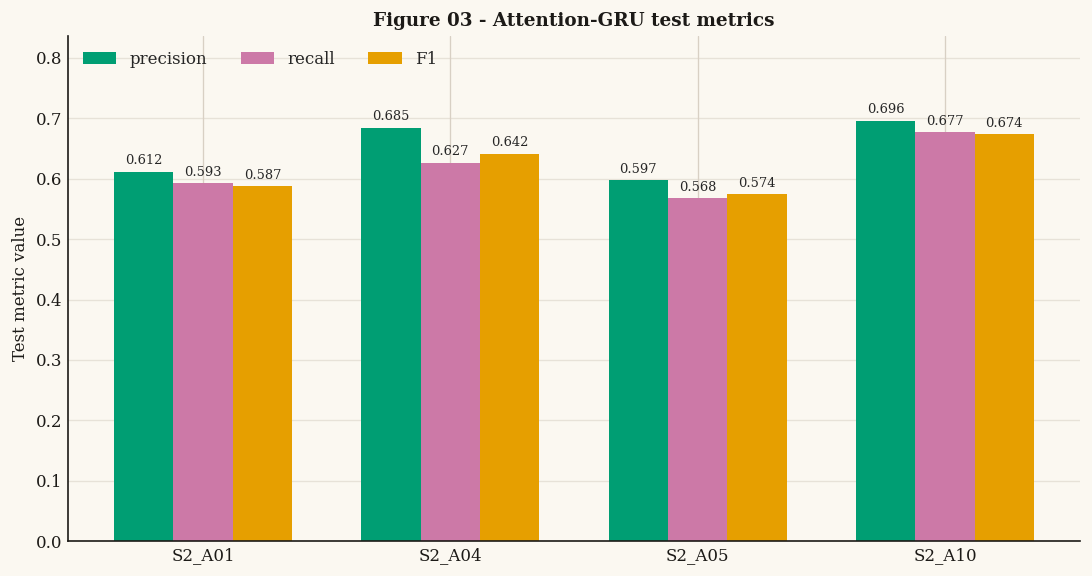

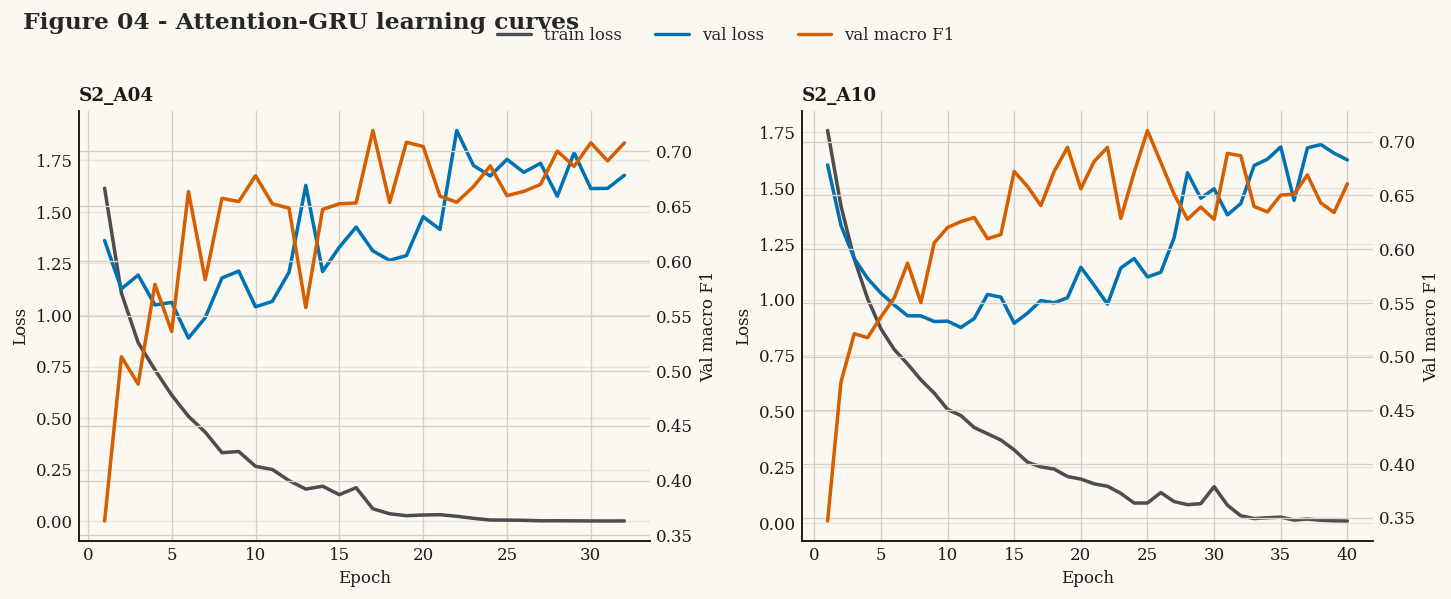

In [32]:
def fig03():
    d=rowsel(S2); mets=['test_macro_precision','test_macro_recall','test_macro_f1']; labs=['precision','recall','F1']; cols=[C['precision'],C['recall'],C['f1']]; x=np.arange(len(d)); w=.24; fig,ax=plt.subplots(figsize=(9.2,4.9))
    for off,m,l,col in zip([-w,0,w],mets,labs,cols):
        vals=d[m].astype(float); ax.bar(x+off,vals,w,label=l,color=col)
        for xi,yi in zip(x+off,vals): ax.text(xi,yi+.012,f'{yi:.3f}',ha='center',fontsize=7.8)
    ax.set(title='Figure 03 - Attention-GRU test metrics',ylabel='Test metric value',xticks=x,xticklabels=d.run_code,ylim=(0,max(d[mets].max())+.14)); ax.title.set_fontweight('bold'); ax.grid(axis='y',alpha=.55); ax.legend(frameon=False,ncol=3,loc='upper left'); savefig(fig,'fig03_attention_test_metrics.png','Attention-GRU test precision, recall, and F1')
fig03(); curves(['S2_A04','S2_A10'],'fig04_attention_learning_curves.png','Figure 04 - Attention-GRU learning curves')


## Classifier diagnosis


Table 2 - Classifier test metrics


,stage/run,precision,recall,F1,accuracy
0,S1_G04,0.6681,0.6574,0.6551,0.7194
1,S1_G05,0.6838,0.6527,0.6594,0.7050
2,S1_G06,0.6928,0.6661,0.6593,0.7194
3,S1_G07,0.5914,0.6035,0.5813,0.6331
4,S2_A01,0.6120,0.5930,0.5874,0.6619
5,S2_A04,0.6846,0.6268,0.6415,0.6906
6,S2_A05,0.5972,0.5676,0.5744,0.6331
7,S2_A10,0.6964,0.6768,0.6741,0.7050
8,S4_F01,0.6346,0.6212,0.6197,0.6763
9,S4_F02,0.6640,0.6659,0.6621,0.7122


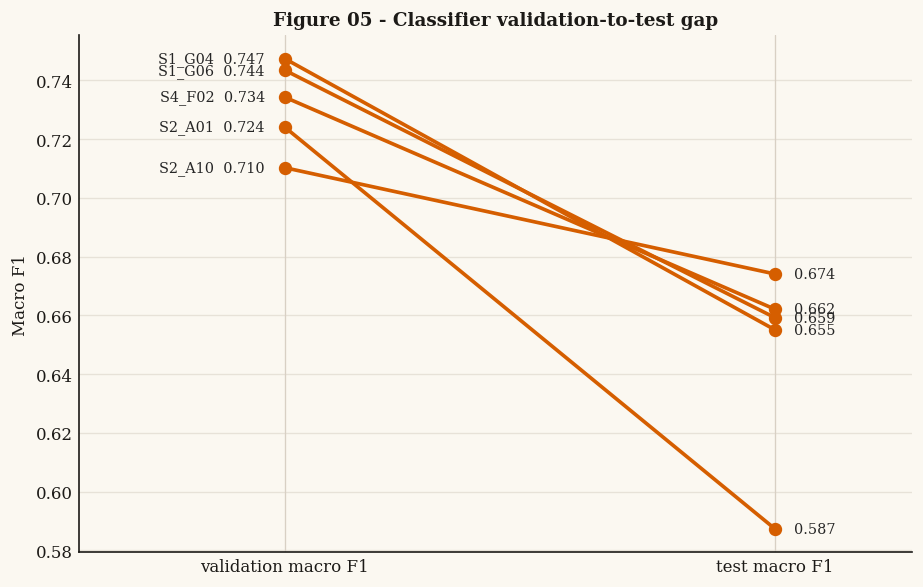

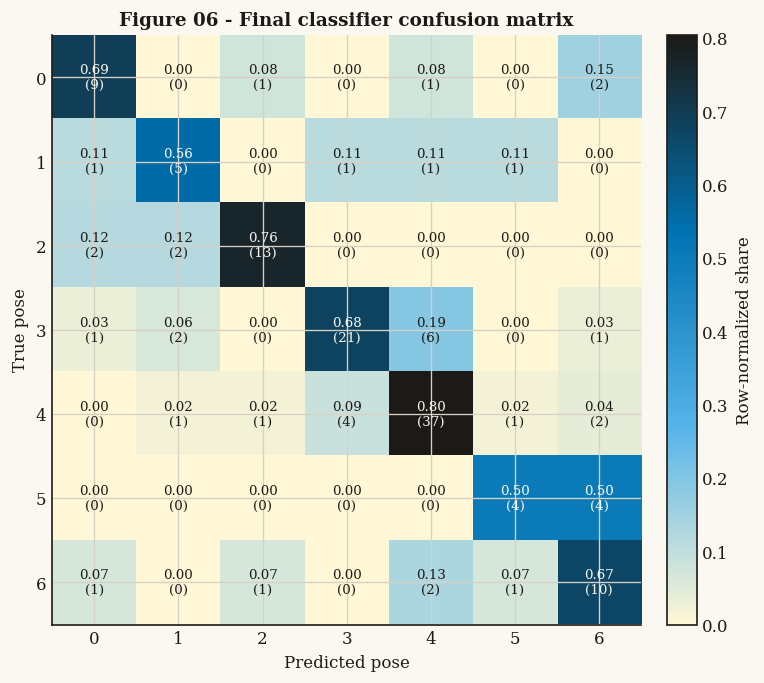

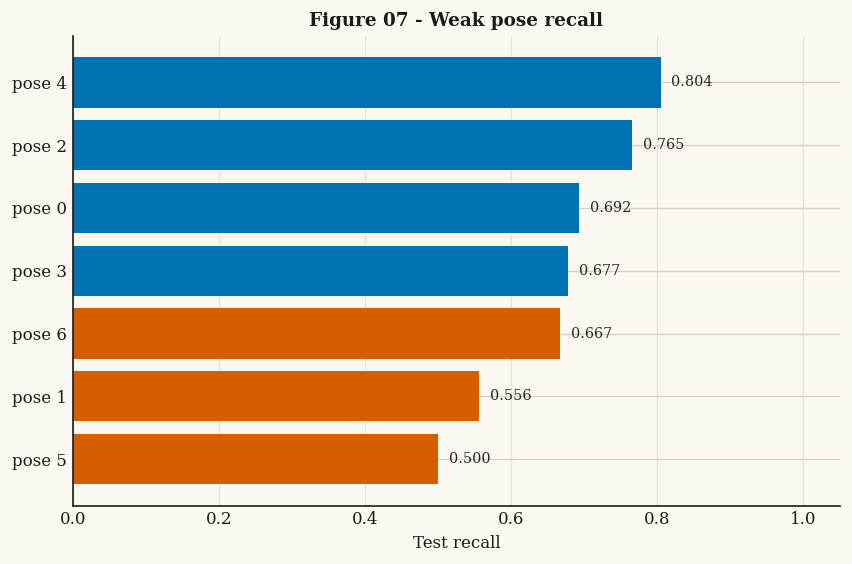

In [33]:
ct=rowsel(S1+S2+['S4_F01','S4_F02'])
table2=pd.DataFrame({'stage/run':ct.run_code,'precision':ct.test_macro_precision.round(4),'recall':ct.test_macro_recall.round(4),'F1':ct.test_macro_f1.round(4),'accuracy':ct.test_accuracy.round(4)})
print('Table 2 - Classifier test metrics'); display(table2)
def fig05():
    d=rowsel(GAP); fig,ax=plt.subplots(figsize=(7.8,5.0))
    for _,r in d.iterrows():
        vals=[r.best_val_macro_f1,r.test_macro_f1]; col=C['test'] if vals[1]<vals[0] else C['good']; ax.plot([0,1],vals,marker='o',ms=7,lw=2.2,color=col); ax.text(-.04,vals[0],f"{r.run_code}  {vals[0]:.3f}",ha='right',va='center',fontsize=8.6); ax.text(1.04,vals[1],f'{vals[1]:.3f}',ha='left',va='center',fontsize=8.6)
    ax.set(title='Figure 05 - Classifier validation-to-test gap',xticks=[0,1],xticklabels=['validation macro F1','test macro F1'],xlim=(-.42,1.28),ylabel='Macro F1'); ax.title.set_fontweight('bold'); ax.grid(axis='y',alpha=.55); savefig(fig,'fig05_classifier_validation_to_test_gap.png','Validation-to-test macro F1 slope chart')
def fig06():
    mat=cm(pred(FC)); norm=mat.div(mat.sum(axis=1).replace(0,np.nan),axis=0).fillna(0); fig,ax=plt.subplots(figsize=(6.4,5.8)); im=ax.imshow(norm.values,cmap=CONF,aspect='equal',vmin=0,vmax=max(.01,norm.values.max()))
    ax.set(title='Figure 06 - Final classifier confusion matrix',xlabel='Predicted pose',ylabel='True pose',xticks=np.arange(len(mat.columns)),yticks=np.arange(len(mat.index))); ax.set_xticklabels(mat.columns); ax.set_yticklabels(mat.index); ax.title.set_fontweight('bold')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v=norm.iloc[i,j]; ax.text(j,i,f'{v:.2f}\n({mat.iloc[i,j]})',ha='center',va='center',fontsize=8,color=C['paper'] if v>norm.values.max()*.55 else C['ink'])
    fig.colorbar(im,ax=ax,fraction=.046,pad=.04,label='Row-normalized share'); savefig(fig,'fig06_final_classifier_confusion_matrix.png','Row-normalized S4_F02 confusion matrix with counts')
def fig07():
    mat=cm(pred(FC)); rec=np.diag(mat.values)/mat.sum(axis=1).replace(0,np.nan).values; d=pd.DataFrame({'pose':mat.index.astype(int),'recall':rec}).sort_values('recall'); fig,ax=plt.subplots(figsize=(7.2,4.8)); ax.barh([f'pose {p}' for p in d.pose],d.recall,color=[C['error'] if v<np.nanmedian(d.recall) else C['val'] for v in d.recall])
    for yi,v in enumerate(d.recall): ax.text(v+.015,yi,f'{v:.3f}',va='center',fontsize=8.6)
    ax.set(title='Figure 07 - Weak pose recall',xlabel='Test recall',xlim=(0,1.05)); ax.title.set_fontweight('bold'); ax.grid(axis='x',alpha=.55); savefig(fig,'fig07_weak_pose_recall.png','Per-class recall for S4_F02')
fig05(); fig06(); fig07()


## Stage 3 - Multi-output bottleneck


Table 3 - Multi-output test metrics


,run,pose F1,presence F1,cell F1,exact accuracy,center mean error,RMSE
0,S3_M09,0.6248,0.6545,0.1455,0.2308,0.6978,0.7988
1,S3_M02,0.6857,0.6919,0.1561,0.2385,0.7527,0.8689
2,S3_M05,0.6755,0.7030,0.1068,0.2077,0.7274,0.8393
3,S3_M04,0.6218,0.7334,0.1223,0.1846,0.7493,0.8548
4,S4_F04,0.6019,0.6103,0.1182,0.1615,0.7395,0.8343
5,S4_F05,0.6549,0.7264,0.1403,0.2462,0.7050,0.8140
6,S4_F06,0.6696,0.6919,0.2066,0.2692,0.7246,0.8698
7,S4_F08,0.6355,0.6545,0.1166,0.2077,0.7171,0.8265


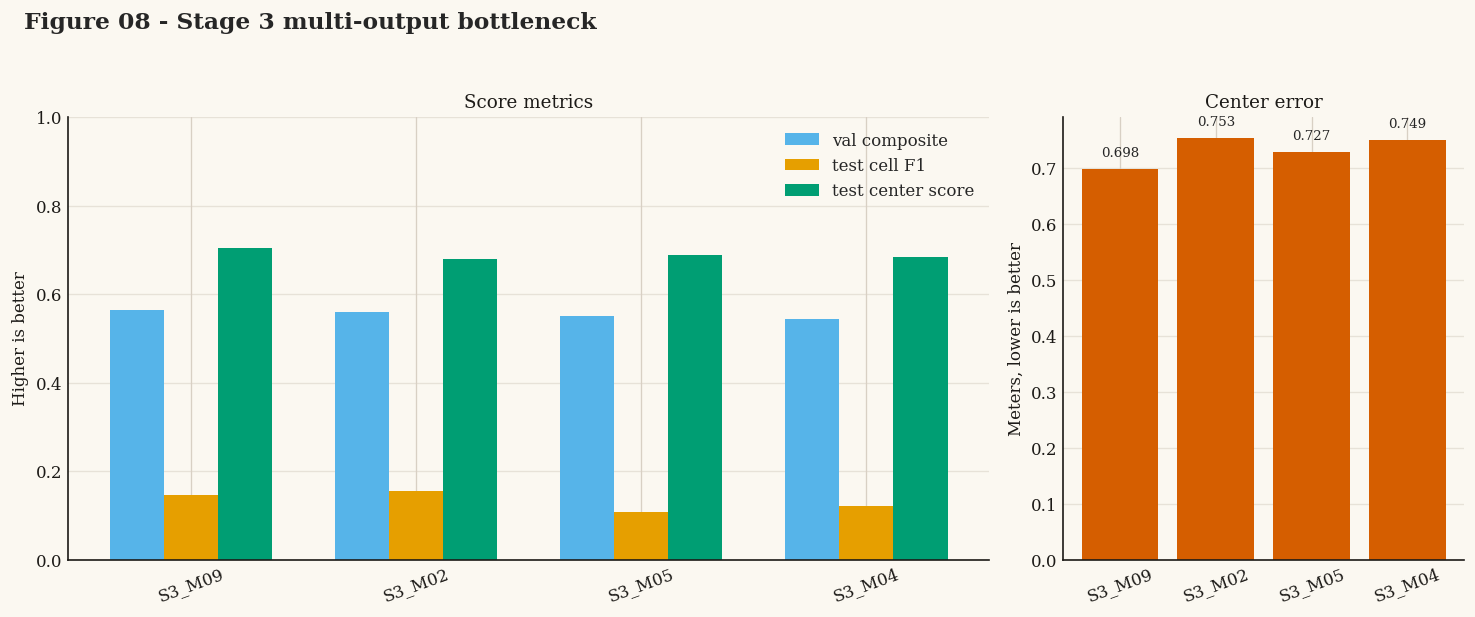

In [34]:
mt=rowsel(S3+S4M)
table3=pd.DataFrame({'run':mt.run_code,'pose F1':mt.test_pose_macro_f1.round(4),'presence F1':mt.test_presence_macro_f1.round(4),'cell F1':mt.test_cell_masked_macro_f1.round(4),'exact accuracy':mt.test_cell_masked_accuracy.round(4),'center mean error':mt.test_center_mean_error_m.round(4),'RMSE':mt.test_center_m_rmse.round(4)})
print('Table 3 - Multi-output test metrics'); display(table3)
def score_err(codes,name,title,score_mets,err='test_center_mean_error_m'):
    d=rowsel(codes); x=np.arange(len(d)); fig,ax=plt.subplots(1,2,figsize=(12.4,4.9),gridspec_kw={'width_ratios':[2.3,1]}); w=.24
    for off,(m,l),col in zip(np.linspace(-w,w,len(score_mets)),score_mets,[C['score'],C['f1'],C['good']]): ax[0].bar(x+off,d[m].astype(float),w,label=l,color=col)
    ax[0].set(title='Score metrics',ylabel='Higher is better',xticks=x,xticklabels=d.run_code,ylim=(0,max(1,d[[m for m,_ in score_mets]].max().max()+.08))); ax[0].tick_params(axis='x',rotation=20); ax[0].grid(axis='y',alpha=.55); ax[0].legend(frameon=False)
    e=d[err].astype(float); ax[1].bar(d.run_code,e,color=C['error']); ax[1].set(title='Center error',ylabel='Meters, lower is better'); ax[1].tick_params(axis='x',rotation=20); ax[1].grid(axis='y',alpha=.55)
    for xi,yi in zip(range(len(d)),e): ax[1].text(xi,yi+max(e)*.03,f'{yi:.3f}',ha='center',fontsize=8)
    fig.suptitle(title,x=.02,y=1.04,ha='left',fontsize=14,fontweight='bold'); savefig(fig,name,title)
score_err(S3,'fig08_stage3_multioutput_bottleneck.png','Figure 08 - Stage 3 multi-output bottleneck',[('best_val_composite_score','val composite'),('test_cell_masked_macro_f1','test cell F1'),('test_center_score','test center score')])


## Stage 4 - Final confirmation and ablation


Table 4 - Final ablation summary


,run,ablation/technique,cell F1,exact accuracy,center error
0,S4_F04,Final multi-output top branch seed 44,0.1182,0.1615,0.7395
1,S4_F05,Final multi-output second branch seed 43,0.1403,0.2462,0.7050
2,S4_F06,Ablation: linear cell head,0.2066,0.2692,0.7246
3,S4_F08,Ablation: layer/capacity,0.1166,0.2077,0.7171


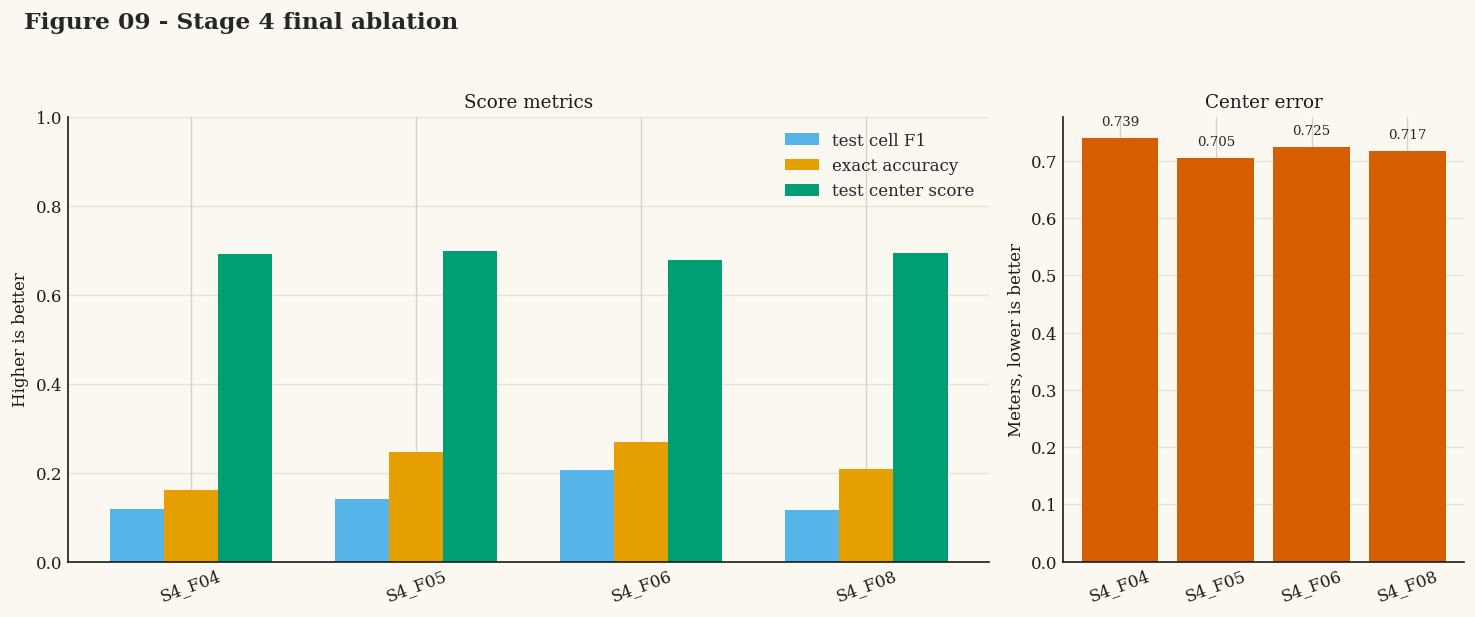

In [35]:
ab=rowsel(S4M)
table4=pd.DataFrame({'run':ab.run_code,'ablation/technique':[TECH[c] for c in S4M],'cell F1':ab.test_cell_masked_macro_f1.round(4),'exact accuracy':ab.test_cell_masked_accuracy.round(4),'center error':ab.test_center_mean_error_m.round(4)})
print('Table 4 - Final ablation summary'); display(table4)
score_err(S4M,'fig09_stage4_final_ablation.png','Figure 09 - Stage 4 final ablation',[('test_cell_masked_macro_f1','test cell F1'),('test_cell_masked_accuracy','exact accuracy'),('test_center_score','test center score')])


## Localization and error analysis


Table 5 - Error analysis outputs


,output file,content
0,classifier_wrong_predictions.csv,Selected classifier test rows where predicted ...
1,cell_wrong_predictions.csv,Selected multi-output test rows where predicte...
2,worst_center_errors.csv,Largest selected multi-output test rows by cen...


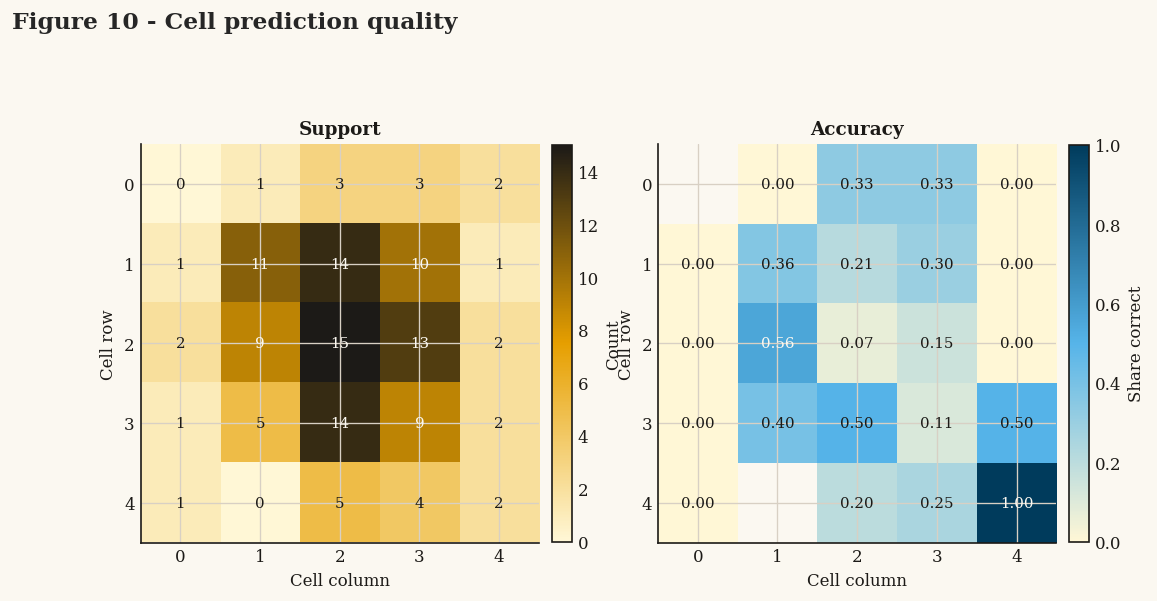

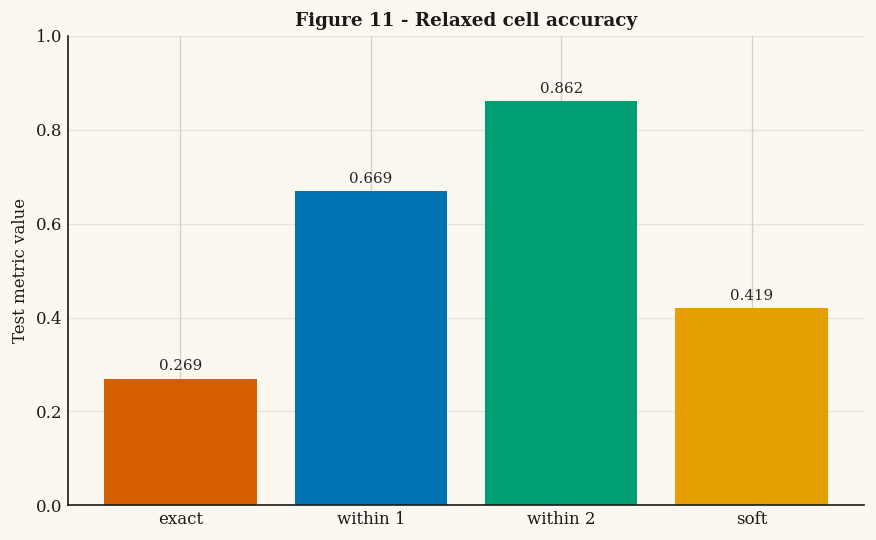

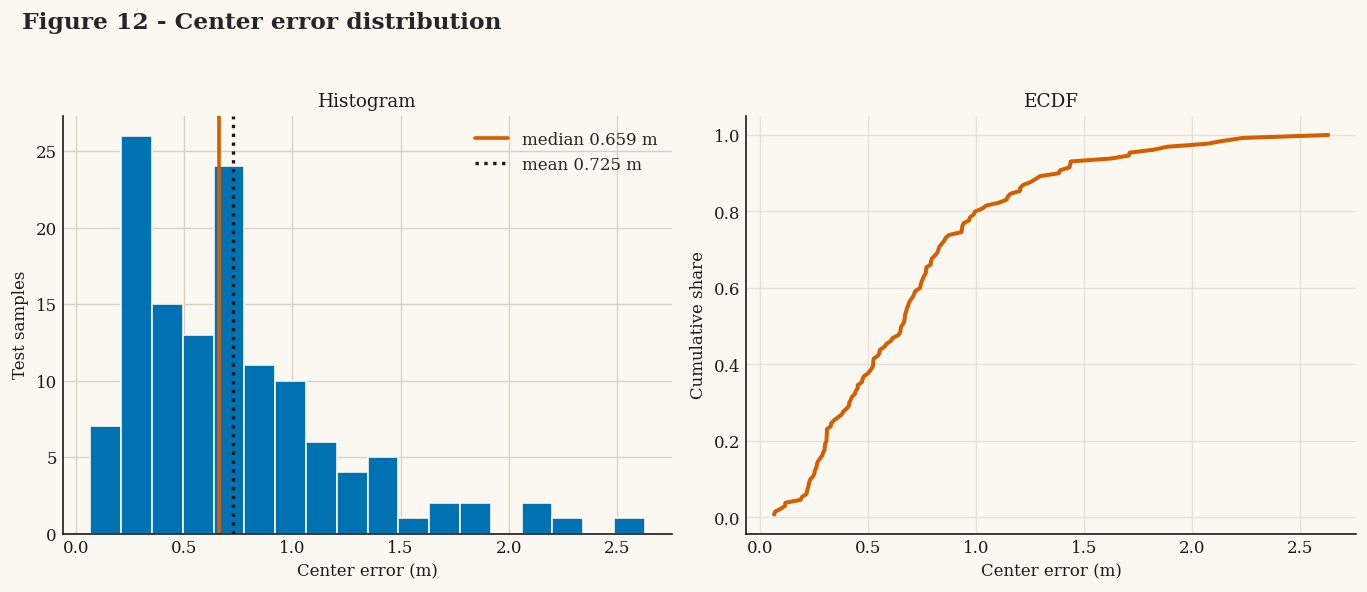

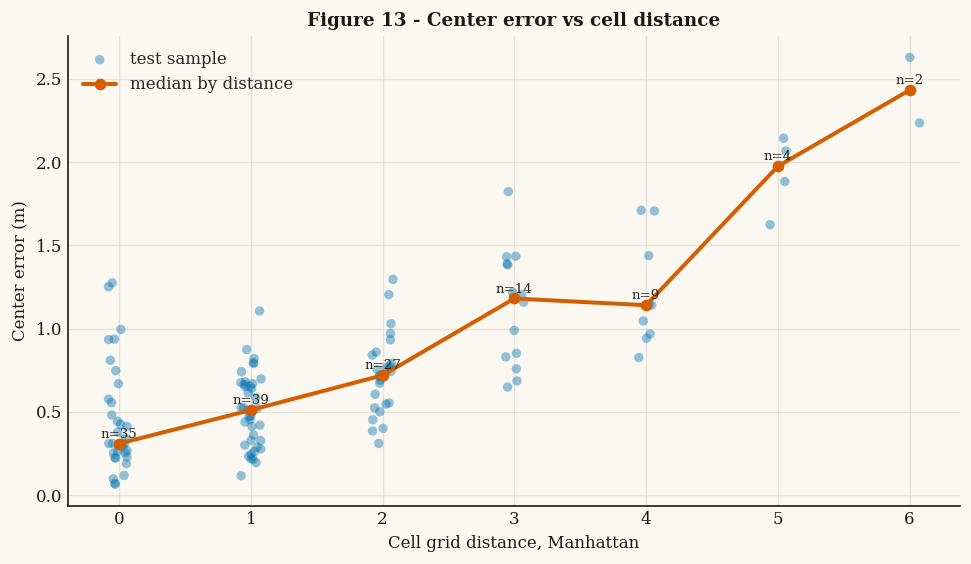

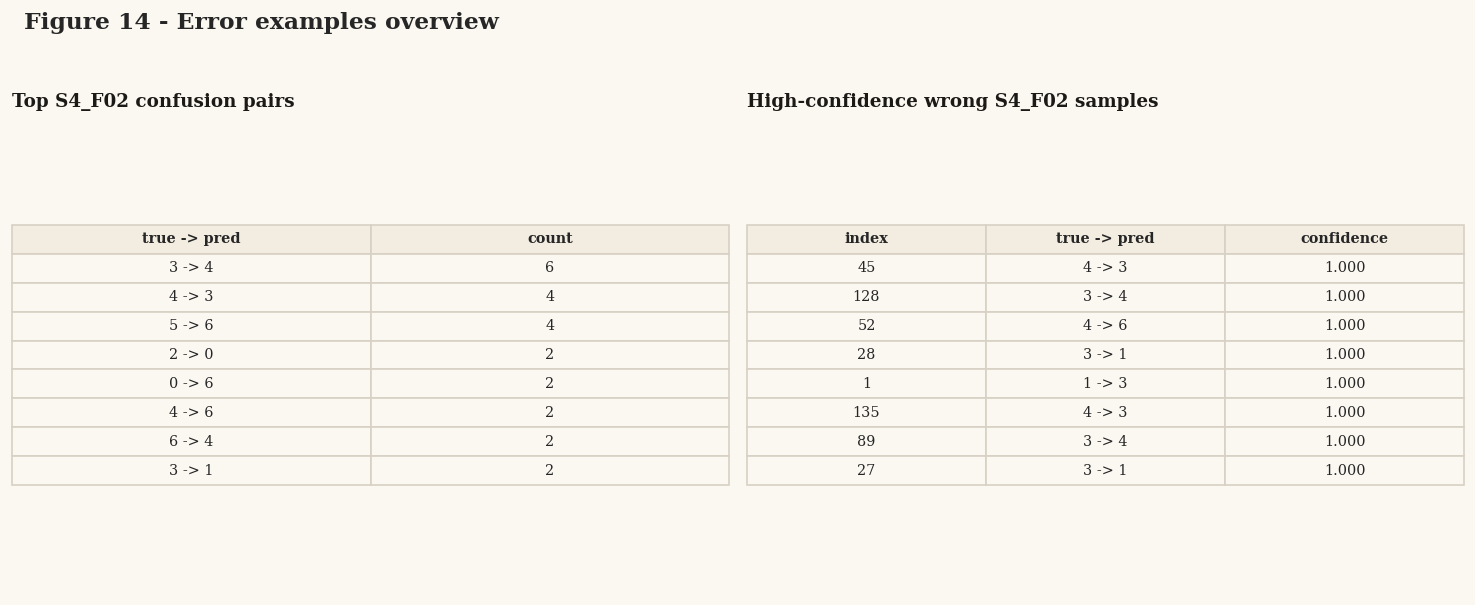

In [36]:
def xy(v): v=pd.Series(v).astype(int); return v%5,v//5
def human(c):
    d=pred(c); return d[d.split.eq('test') & d.cell_label_human.ge(0)].copy()
def dist(d):
    d=d.copy(); ax,ay=xy(d.cell_label_human); px,py=xy(d.cell_pred); d['cell_grid_l1_distance']=(ax-px).abs()+(ay-py).abs(); d['cell_grid_linf_distance']=np.maximum((ax-px).abs(),(ay-py).abs()); return d
cw=[]
for c in S1+S2+['S4_F01','S4_F02']:
    d=pred(c); w=d[d.split.eq('test') & ~d.label.eq(d.prediction)].copy(); w.insert(0,'run_code',c); w.insert(0,'stage',stage(c)); cw.append(w[['stage','run_code','split','index','label','prediction','confidence']])
classifier_wrong=pd.concat(cw,ignore_index=True)
cell_parts=[]; center_parts=[]
for c in S3+S4M:
    d=dist(human(c)); w=d[~d.cell_label_human.astype(int).eq(d.cell_pred.astype(int))].copy(); w.insert(0,'run_code',c); w.insert(0,'stage',stage(c)); cell_parts.append(w[['stage','run_code','split','index','cell_label_human','cell_pred','cell_confidence','cell_grid_l1_distance','cell_grid_linf_distance','center_error_m']]); z=d.sort_values('center_error_m',ascending=False).copy(); z.insert(0,'run_code',c); z.insert(0,'stage',stage(c)); center_parts.append(z[['stage','run_code','split','index','cell_label_human','cell_pred','cell_grid_l1_distance','center_x_m_label','center_y_m_label','center_x_m_pred','center_y_m_pred','center_error_m']])
cell_wrong=pd.concat(cell_parts,ignore_index=True); worst_center=pd.concat(center_parts,ignore_index=True).sort_values('center_error_m',ascending=False).head(80)
savecsv(classifier_wrong,'classifier_wrong_predictions.csv','Selected classifier wrong predictions'); savecsv(cell_wrong,'cell_wrong_predictions.csv','Selected cell wrong predictions'); savecsv(worst_center,'worst_center_errors.csv','Largest center errors')
table5=pd.DataFrame({'output file':CSV_FILES,'content':['Selected classifier test rows where predicted pose differs from label.','Selected multi-output test rows where predicted cell differs from true human cell.','Largest selected multi-output test rows by center error in meters.']})
print('Table 5 - Error analysis outputs'); display(table5)
def fig10():
    d=human(FM); sup=np.zeros((5,5),int); cor=np.zeros((5,5),int)
    for _,r in d.iterrows():
        c=int(r.cell_label_human); x,y=c%5,c//5; sup[y,x]+=1; cor[y,x]+=int(int(r.cell_pred)==c)
    acc=np.divide(cor,sup,out=np.full_like(cor,np.nan,dtype=float),where=sup>0); fig,ax=plt.subplots(1,2,figsize=(10.2,4.9),constrained_layout=True)
    for a,data,cmap,title,label in [(ax[0],sup,SUPPORT,'Support','Count'),(ax[1],acc,SCORE,'Accuracy','Share correct')]:
        im=a.imshow(data,cmap=cmap,aspect='equal',vmin=0,vmax=np.nanmax(data)); a.set(title=title,xlabel='Cell column',ylabel='Cell row',xticks=range(5),yticks=range(5)); a.title.set_fontweight('bold')
        for y in range(5):
            for x in range(5):
                v=data[y,x]; txt=f'{int(v)}' if title=='Support' else ('' if np.isnan(v) else f'{v:.2f}'); a.text(x,y,txt,ha='center',va='center',fontsize=9,color=C['paper'] if not np.isnan(v) and v>np.nanmax(data)*.55 else C['ink'])
        fig.colorbar(im,ax=a,fraction=.046,pad=.03,label=label)
    fig.suptitle('Figure 10 - Cell prediction quality',x=.02,y=1.06,ha='left',fontsize=14,fontweight='bold'); savefig(fig,'fig10_cell_prediction_quality.png','S4_F06 5x5 support and accuracy heatmaps')
def fig11():
    r=relrow(FM); labs=['exact','within 1','within 2','soft']; vals=[r.get('cell_masked_accuracy',np.nan),r.get('cell_within_1cell',np.nan),r.get('cell_within_2cell',np.nan),r.get('cell_relaxed_soft_score',np.nan)]; fig,ax=plt.subplots(figsize=(7.4,4.6)); ax.bar(labs,vals,color=[C['test'],C['val'],C['good'],C['f1']])
    for i,v in enumerate(vals): ax.text(i,v+.018,f'{v:.3f}',ha='center',fontsize=9)
    ax.set(title='Figure 11 - Relaxed cell accuracy',ylabel='Test metric value',ylim=(0,1)); ax.title.set_fontweight('bold'); ax.grid(axis='y',alpha=.55); savefig(fig,'fig11_relaxed_cell_accuracy.png','S4_F06 relaxed localization metrics')
def fig12():
    e=np.sort(human(FM).center_error_m.dropna().to_numpy()); fig,ax=plt.subplots(1,2,figsize=(11.5,4.7)); ax[0].hist(e,bins=18,color=C['val'],edgecolor=C['paper']); ax[0].axvline(np.median(e),color=C['test'],lw=2.2,label=f'median {np.median(e):.3f} m'); ax[0].axvline(np.mean(e),color=C['ink'],lw=2,ls=':',label=f'mean {np.mean(e):.3f} m'); ax[0].set(title='Histogram',xlabel='Center error (m)',ylabel='Test samples'); ax[0].legend(frameon=False); ax[1].plot(e,np.arange(1,len(e)+1)/len(e),color=C['test'],lw=2.4); ax[1].set(title='ECDF',xlabel='Center error (m)',ylabel='Cumulative share'); ax[1].grid(alpha=.55); fig.suptitle('Figure 12 - Center error distribution',x=.02,y=1.04,ha='left',fontsize=14,fontweight='bold'); savefig(fig,'fig12_center_error_distribution.png','S4_F06 center error histogram and ECDF')
def fig13():
    d=dist(human(FM)); g=d.groupby('cell_grid_l1_distance',as_index=False).center_error_m.agg(['median','count']).reset_index(); fig,ax=plt.subplots(figsize=(8.2,4.8)); rng=np.random.default_rng(7); ax.scatter(d.cell_grid_l1_distance+rng.uniform(-.08,.08,len(d)),d.center_error_m,s=32,color=C['val'],alpha=.42,edgecolor='none',label='test sample'); ax.plot(g.cell_grid_l1_distance,g['median'],color=C['test'],marker='o',lw=2.4,label='median by distance')
    for _,r in g.iterrows(): ax.text(r.cell_grid_l1_distance,r['median']+.035,f"n={int(r['count'])}",ha='center',fontsize=8)
    ax.set(title='Figure 13 - Center error vs cell distance',xlabel='Cell grid distance, Manhattan',ylabel='Center error (m)'); ax.title.set_fontweight('bold'); ax.grid(alpha=.55); ax.legend(frameon=False); savefig(fig,'fig13_center_error_vs_cell_distance.png','S4_F06 center error against cell grid distance')
def fig14():
    f=classifier_wrong[classifier_wrong.run_code.eq(FC)].copy(); pairs=f.groupby(['label','prediction'],as_index=False).size().sort_values('size',ascending=False).head(8); pairs['pair']=pairs.label.astype(str)+' -> '+pairs.prediction.astype(str); hi=f.sort_values('confidence',ascending=False).head(8).copy(); hi['sample']=hi['index'].astype(int).astype(str); hi['true -> pred']=hi.label.astype(str)+' -> '+hi.prediction.astype(str); hi['confidence']=hi.confidence.map(lambda v:f'{v:.3f}'); fig,ax=plt.subplots(1,2,figsize=(12.4,4.8))
    for a in ax: a.axis('off')
    ax[0].set_title('Top S4_F02 confusion pairs',loc='left',fontweight='bold'); ax[1].set_title('High-confidence wrong S4_F02 samples',loc='left',fontweight='bold'); t1=ax[0].table(cellText=pairs[['pair','size']].values,colLabels=['true -> pred','count'],loc='center',cellLoc='center'); t2=ax[1].table(cellText=hi[['sample','true -> pred','confidence']].values,colLabels=['index','true -> pred','confidence'],loc='center',cellLoc='center')
    for t in [t1,t2]:
        t.auto_set_font_size(False); t.set_fontsize(8.6); t.scale(1,1.35)
        for (r,c),ce in t.get_celld().items(): ce.set_edgecolor(C['grid']); ce.set_facecolor(C['panel'] if r==0 else C['paper']); ce.set_text_props(weight='bold' if r==0 else 'normal')
    fig.suptitle('Figure 14 - Error examples overview',x=.02,y=1.04,ha='left',fontsize=14,fontweight='bold'); savefig(fig,'fig14_error_examples_overview.png','Top confusion pairs and high-confidence wrong classifier predictions')
fig10(); fig11(); fig12(); fig13(); fig14()


## Final compact scorecard


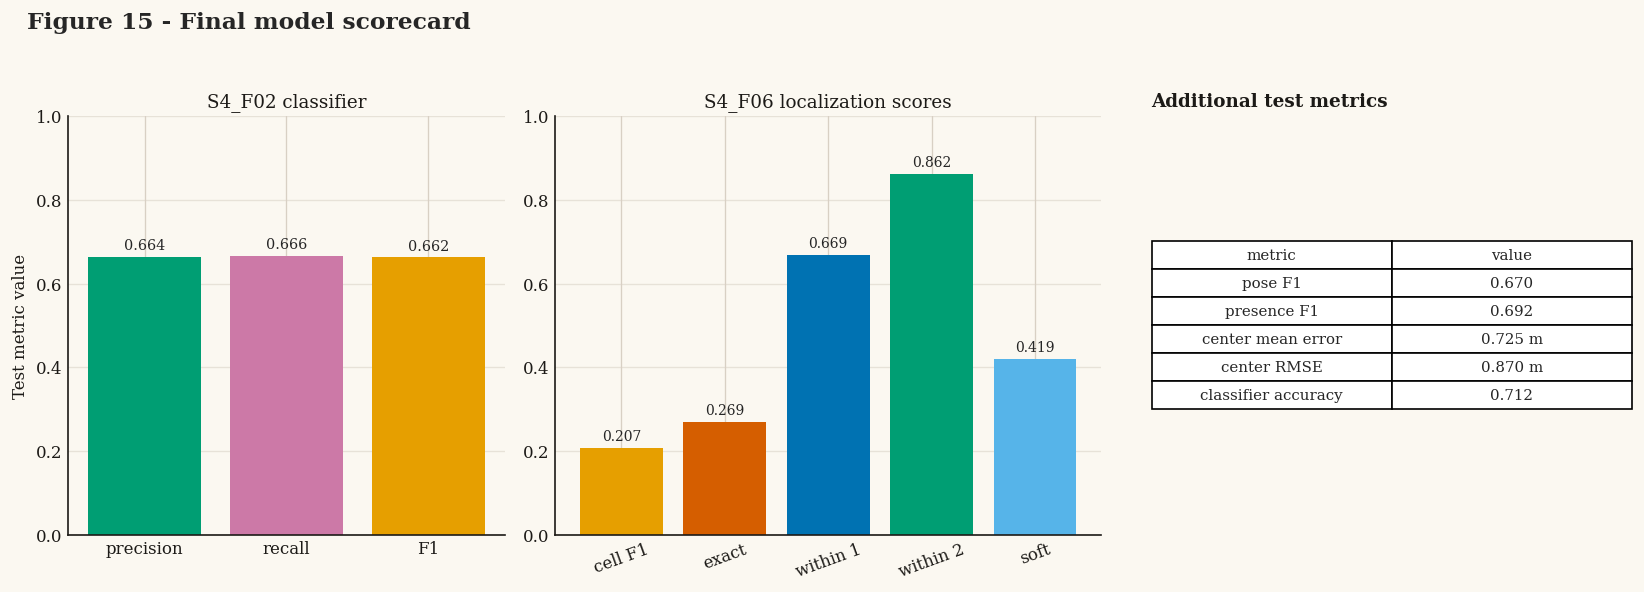

In [37]:
def fig15():
    cl=row(FC); mo=row(FM); r=relrow(FM); fig,ax=plt.subplots(1,3,figsize=(13.8,4.7),gridspec_kw={'width_ratios':[1,1.25,1.1]}); vals=[cl.test_macro_precision,cl.test_macro_recall,cl.test_macro_f1]; ax[0].bar(['precision','recall','F1'],vals,color=[C['precision'],C['recall'],C['f1']]); ax[0].set(title='S4_F02 classifier',ylabel='Test metric value',ylim=(0,1)); ax[0].grid(axis='y',alpha=.55)
    for i,v in enumerate(vals): ax[0].text(i,v+.018,f'{v:.3f}',ha='center',fontsize=8.6)
    labs=['cell F1','exact','within 1','within 2','soft']; loc=[mo.test_cell_masked_macro_f1,r.get('cell_masked_accuracy',mo.test_cell_masked_accuracy),r.get('cell_within_1cell',np.nan),r.get('cell_within_2cell',np.nan),r.get('cell_relaxed_soft_score',np.nan)]; ax[1].bar(labs,loc,color=[C['f1'],C['test'],C['val'],C['good'],C['score']]); ax[1].set(title='S4_F06 localization scores',ylim=(0,1)); ax[1].tick_params(axis='x',rotation=20); ax[1].grid(axis='y',alpha=.55)
    for i,v in enumerate(loc): ax[1].text(i,v+.018,f'{v:.3f}',ha='center',fontsize=8.3)
    ax[2].axis('off'); data=[['pose F1',f'{mo.test_pose_macro_f1:.3f}'],['presence F1',f'{mo.test_presence_macro_f1:.3f}'],['center mean error',f'{mo.test_center_mean_error_m:.3f} m'],['center RMSE',f'{mo.test_center_m_rmse:.3f} m'],['classifier accuracy',f'{cl.test_accuracy:.3f}']]; tt=ax[2].table(cellText=data,colLabels=['metric','value'],loc='center',cellLoc='center'); tt.auto_set_font_size(False); tt.set_fontsize(9); tt.scale(1,1.45); ax[2].set_title('Additional test metrics',loc='left',fontweight='bold')
    fig.suptitle('Figure 15 - Final model scorecard',x=.02,y=1.04,ha='left',fontsize=14,fontweight='bold'); savefig(fig,'fig15_final_model_scorecard.png','Final selected classifier and multi-output scorecard')
fig15()
